<a href="https://colab.research.google.com/github/keivernunez/dataminingavanzado_austral/blob/main/Note2_de_4_Spacy_Transfrormer_avanzado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelos Transformer para Traducción Automática (PT-EN) con SpaCy y Transformers

En este cuaderno se explora la implementación de un modelo Transformer para la traducción automática de portugués a inglés. Utiliceremos **SpaCy** no para su pipeline tradicional, sino como un orquestador eficiente para un modelo de traducción secuencia a secuencia (seq2seq) de **Hugging Face**.

Aprovecharemos la eficiencia de SpaCy para el procesamiento de texto (como la tokenización precisa del portugués) y su capacidad para integrar modelos de transformers para una inferencia rápida y escalable.

## Contexto: "Attention is All You Need"

Este trabajo se basa en la arquitectura **Transformer**, introducida en el artículo seminal "Attention is All You Need" (Vaswani et al., 2017). Esta arquitectura revolucionó el NLP al reemplazar las arquitecturas recurrentes (RNN/LSTM) por un mecanismo basado puramente en **auto-atención** (*self-attention*). Esto permite al modelo sopesar la importancia de diferentes palabras en una secuencia simultáneamente, capturando dependencias a larga distancia de manera mucho más eficaz y permitiendo una paralelización masiva durante el entrenamiento.

## Objetivos de Aprendizaje

- Comprender cómo integrar modelos de Hugging Face (como `Helsinki-NLP`) dentro de un pipeline de SpaCy.
- Usar la biblioteca `spacy-huggingface-pipelines` para tareas de traducción.
- Cargar y preprocesar datos de texto paralelo usando la biblioteca `datasets`.
- Realizar inferencia en lote (`nlp.pipe`) para optimizar la velocidad.
- Evaluar la **calidad** de la traducción usando la métrica estándar `sacrebleu` (BLEU).
- Medir y visualizar el **rendimiento** (latencia de inferencia) y su relación con la longitud de las frases.

## 1. Instalación y Configuración del Entorno

Primero, instalamos las bibliotecas necesarias. **Importante:** Este cuaderno requiere una GPU para ejecutarse en un tiempo razonable. Asegúrate de seleccionar un "Entorno de ejecución con GPU" en Colab (`Entorno de ejecución > Cambiar tipo de entorno de ejecución > Acelerador de hardware > T4 GPU`).

**Nota sobre la instalación (El Conflicto 'Catch-22'):**
1.  Necesitamos `spacy==3.7.4` (para el modelo `pt_core...`).
2.  `spacy==3.7.4` requiere `numpy 1.x`.
3.  `spacy` carga el plugin `spacy-huggingface-pipelines`, que importa `transformers`.
4.  `transformers` importa `tensorflow` (incluso si no se usa).
5.  El `tensorflow` de Colab requiere `numpy 2.x` (conflicto 1).

**La solución (Segura para re-ejecutar):**
1. Desinstalar los paquetes en conflicto (`cupy`, `jax`).
2. Instalar **explícitamente** las versiones que necesitamos (`spacy 3.7.4`, `scipy < 1.13`, `tensorflow 2.16.1`).
3. `pip` automáticamente reemplazará la versión de `tensorflow` de Colab por la nuestra (2.16.1) sin que tengamos que desinstalarla manualmente.

# No olvidar habilitar GPU T4

In [ ]:
# --- Importaciones ---
from datasets import load_dataset
import spacy
from transformers import MarianMTModel, MarianTokenizer
import torch

# --- Configuración del Dataset ---
DATASET_NAME = "yehzw/ted_hrlr"
DATASET_CONFIG = "pt_to_en"
DATA_SPLIT = "test"
SAMPLE_SIZE = 500

# --- Instalar librerías necesarias ---
!pip install -q transformers torch datasets sacremoses sacrebleu

# --- Instalar sacremoses, un "helper" (auxiliar) en tokenización ---

sacremoses_url = "https://github.com/alvations/sacremoses/archive/master.zip"
!pip install -q {sacremoses_url}

# --- Descargar modelo SpaCy portugués ---
!python -m spacy download pt_core_news_lg

# --- Cargar dataset y seleccionar muestra ---
print(f"Cargando dataset: {DATASET_NAME} ({DATASET_CONFIG})...")
dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split=DATA_SPLIT)
dataset = dataset.shuffle(seed=42).select(range(SAMPLE_SIZE))
print(f"Dataset cargado con {len(dataset)} ejemplos seleccionados.")

# --- Cargar modelo SpaCy ---
MODELO_BASE_PT = "pt_core_news_lg"
print(f"Cargando modelo base de SpaCy: {MODELO_BASE_PT}...")
nlp = spacy.load(MODELO_BASE_PT)

# --- Cargar modelo Hugging Face funcional ---
MODELO_TRADUCCION_HF = "Helsinki-NLP/opus-mt-ROMANCE-en"
print(f"Cargando modelo de Hugging Face: {MODELO_TRADUCCION_HF}...")
tokenizer = MarianTokenizer.from_pretrained(MODELO_TRADUCCION_HF)
model = MarianMTModel.from_pretrained(MODELO_TRADUCCION_HF)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# --- Función de traducción ---
def traducir_pt_a_en(texto: str) -> str:
    inputs = tokenizer(texto, return_tensors="pt", padding=True).to(device)
    translated_tokens = model.generate(**inputs)
    return tokenizer.decode(translated_tokens[0], skip_special_tokens=True)

# --- Prueba rápida ---
prueba = dataset[0]['translation']['pt']
traduccion = traducir_pt_a_en(prueba)
print(f"\nPT: '{prueba}'")
print(f"EN: '{traduccion}'")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 2.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Cargando dataset: yehzw/ted_hrlr (pt_to_en)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

pt_to_en/train-00000-of-00001.parquet:   0%|          | 0.00/5.94M [00:00<?, ?B/s]

pt_to_en/validation-00000-of-00001.parqu(…):   0%|          | 0.00/131k [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


pytorch_model.bin:   0%|          | 0.00/312M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/312M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/293 [00:00<?, ?B/s]


PT: '( risos ) ( aplausos ) não aconteceu nada disso . ( risos )'
EN: '( laughs ) ( applause ) none of this happened . ( laughs )'

Traducciones completadas para 500 ejemplos.


### ⚠️ ¡Acción Requerida! ⚠️

Para que las instalaciones (especialmente las versiones de `numpy` y `tensorflow`) se carguen correctamente, debes **REINICIAR EL ENTORNO DE EJECUCIÓN** ahora.

Ve a: **`Entorno de ejecución > Reiniciar sesión`**

Después de reiniciar, **NO** vuelvas a ejecutar la celda de instalación de arriba. Simplemente continúa con la celda de `import spacy` que sigue a continuación.

In [ ]:
print("Importando bibliotecas...")
import spacy
import torch
import time
from datasets import load_dataset
from sacrebleu.metrics import BLEU
import matplotlib.pyplot as plt
import numpy as np
from spacy.tokens import Doc
from huggingface_hub import notebook_login

print("¡Importación exitosa!")

# Verificar si la GPU está disponible y activarla para SpaCy
if torch.cuda.is_available():
    print("GPU detectada. Activando spacy.require_gpu().")
    spacy.require_gpu()
else:
    print("GPU no detectada. El proceso será lento.")

Importando bibliotecas...
¡Importación exitosa!
GPU detectada. Activando spacy.require_gpu().


## 1.5. Autenticación en Hugging Face (Solución Error 401)

Un error `401 Unauthorized` (como el que mencionaste) casi siempre significa que Hugging Face está rechazando tu conexión por un token (clave API) inválido, antiguo o inexistente.

La solución más robusta es iniciar sesión explícitamente.

**Pasos a seguir en la siguiente celda:**
1.  Ejecuta la celda.
2.  Te pedirá un token.
3.  Ve a [huggingface.co/settings/tokens](https://huggingface.co/settings/tokens) (necesitas una cuenta gratuita).
4.  Genera un nuevo token (con rol de `read` es suficiente).
5.  Pega el token en el campo de entrada y presiona Enter.

Una vez que veas "Login successful", estarás autenticado y las descargas del modelo y el dataset funcionarán.

In [ ]:
print("Iniciando sesión en Hugging Face Hub...")
notebook_login()

Iniciando sesión en Hugging Face Hub...


## 2. Carga y Preparación de Datos

Ahora que estamos autenticados, podemos descargar el conjunto de datos.

**¡CORRECCIÓN DEFINITIVA!**
El error `RuntimeError` nos dice que `neulab/ted_hrlr` usa un script `.py` (no soportado).
Usaremos `yehzw/ted_hrlr`, que es la versión moderna en formato **Parquet** y que `datasets` puede leer directamente. Este dataset *sí* tiene un split de `test`.

In [ ]:
# --- Traducción sin GPU de todas las muestras ---
traducciones = [traducir_pt_a_en(item['translation']['pt']) for item in dataset]
print(f"\nTraducciones completadas para {len(traducciones)} ejemplos.")

In [ ]:
# --- Traducción con GPU de todas las muestras ---

BATCH_SIZE = 16
traducciones = []

for i in range(0, len(dataset), BATCH_SIZE):
    # Seleccionar batch como lista de diccionarios
    batch = dataset.select(range(i, min(i + BATCH_SIZE, len(dataset))))
    batch_textos = [item['translation']['pt'] for item in batch]

    # Tokenizar batch
    inputs = tokenizer(batch_textos, return_tensors="pt", padding=True, truncation=True).to(device)

    # Generar traducciones
    translated_tokens = model.generate(**inputs)

    # Decodificar batch
    batch_traducciones = [tokenizer.decode(t, skip_special_tokens=True) for t in translated_tokens]
    traducciones.extend(batch_traducciones)

print(f"\nTraducciones completadas para {len(traducciones)} ejemplos.")


Traducciones completadas para 500 ejemplos.


In [ ]:
# --- Carga de Datos Corregida (Usando el dataset Parquet) ---
DATASET_NAME = "yehzw/ted_hrlr"    # ¡El dataset correcto en formato Parquet!
DATASET_CONFIG = "pt_to_en"        # El nombre de la configuración
DATA_SPLIT = "test"                # Este dataset SÍ tiene un split de 'test'
SAMPLE_SIZE = 500

print(f"Cargando dataset: {DATASET_NAME} (config: {DATASET_CONFIG}, split: {DATA_SPLIT})...")

# 1. Cargar el split de 'test' directamente
test_dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split=DATA_SPLIT)

# 2. Mezclar y seleccionar una muestra del conjunto de prueba
test_dataset_sample = test_dataset.shuffle(seed=42).select(range(SAMPLE_SIZE))

# 3. Extraer los textos fuente (portugués) y de referencia (inglés)
source_texts = [item['translation']['pt'] for item in test_dataset_sample]
reference_texts = [item['translation']['en'] for item in test_dataset_sample]

print(f"Datos cargados. {len(source_texts)} frases de muestra.")
print("\n--- Ejemplo de Datos ---")
print(f"Fuente (PT): {source_texts[0]}")
print(f"Referencia (EN): {reference_texts[0]}")

Cargando dataset: yehzw/ted_hrlr (config: pt_to_en, split: test)...
Datos cargados. 500 frases de muestra.

--- Ejemplo de Datos ---
Fuente (PT): ( risos ) ( aplausos ) não aconteceu nada disso . ( risos )
Referencia (EN): ( laughter ) ( applause ) that did not happen . ( laughter )


## 3. Configuración del Pipeline de Traducción en SpaCy

Aquí está el núcleo de nuestra implementación. Haremos lo siguiente:

1.  Cargaremos `pt_core_news_lg`. Este modelo es excelente para tokenizar portugués, lo cual es crucial para que el modelo Transformer reciba *inputs* de alta calidad.
2.  Añadiremos un nuevo componente al pipeline: `hf_pipeline`.
3.  Configuraremos este componente para que use un pipeline de Hugging Face específico: `"translation_pt_to_en"`.
4.  Especificaremos el modelo exacto a usar: `"Helsinki-NLP/opus-mt-pt-en"`. Este es un modelo de la serie OPUS-MT de MarianNMT, conocido por ser ligero y de alta calidad para la traducción.
5.  Estableceremos un `batch_size` (ej. 16 o 32) para que la GPU procese múltiples frases a la vez, aumentando drásticamente el rendimiento.

In [ ]:
from datasets import load_dataset
import spacy
from transformers import MarianMTModel, MarianTokenizer
import torch

# --- Configuración del Dataset ---
DATASET_NAME = "yehzw/ted_hrlr"
DATASET_CONFIG = "pt_to_en"
DATA_SPLIT = "test"
SAMPLE_SIZE = 500

# --- Cargar dataset y seleccionar muestra ---
print(f"Cargando dataset: {DATASET_NAME} ({DATASET_CONFIG})...")
dataset = load_dataset(DATASET_NAME, DATASET_CONFIG, split=DATA_SPLIT)
dataset = dataset.shuffle(seed=42).select(range(SAMPLE_SIZE))
print(f"Dataset cargado con {len(dataset)} ejemplos seleccionados.")

# --- Configuración de SpaCy ---
MODELO_BASE_PT = "pt_core_news_lg"
print(f"Cargando modelo base de SpaCy: {MODELO_BASE_PT}...")
nlp = spacy.load(MODELO_BASE_PT)

# --- Configuración del modelo Hugging Face funcional ---
MODELO_TRADUCCION_HF = "Helsinki-NLP/opus-mt-ROMANCE-en"
print(f"Cargando modelo de Hugging Face: {MODELO_TRADUCCION_HF}...")
tokenizer = MarianTokenizer.from_pretrained(MODELO_TRADUCCION_HF)
model = MarianMTModel.from_pretrained(MODELO_TRADUCCION_HF)
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

# --- Función de traducción ---
def traducir_pt_a_en(texto: str) -> str:
    inputs = tokenizer(texto, return_tensors="pt", padding=True).to(device)
    translated_tokens = model.generate(**inputs)
    return tokenizer.decode(translated_tokens[0], skip_special_tokens=True)

# --- Prueba rápida ---
prueba = dataset[0]['translation']['pt']
traduccion = traducir_pt_a_en(prueba)
print(f"\nPT: '{prueba}'")
print(f"EN: '{traduccion}'")

# --- Traducción de todas las muestras ---
traducciones = [traducir_pt_a_en(item['translation']['pt']) for item in dataset]
print(f"\nTraducciones completadas para {len(traducciones)} ejemplos.")

Cargando dataset: yehzw/ted_hrlr (pt_to_en)...
Dataset cargado con 500 ejemplos seleccionados.
Cargando modelo base de SpaCy: pt_core_news_lg...
Cargando modelo de Hugging Face: Helsinki-NLP/opus-mt-ROMANCE-en...

PT: '( risos ) ( aplausos ) não aconteceu nada disso . ( risos )'
EN: '( laughs ) ( applause ) none of this happened . ( laughs )'

Traducciones completadas para 500 ejemplos.


## 4. Inferencia en Lote y Medición de Rendimiento

En lugar de traducir frase por frase con `nlp(text)`, usaremos `nlp.pipe(texts)`. Este método es mucho más eficiente porque:

1.  Utiliza todos los núcleos de la CPU para la tokenización de SpaCy.
2.  Envía las frases a la GPU en lotes (definidos por nuestro `BATCH_SIZE`), maximizando el uso del hardware.

Mediremos el tiempo total para traducir las 500 frases y calcularemos el rendimiento en **frases por segundo**.

In [ ]:
import time

# --- Preparar los textos fuente ---
source_texts = [item['translation']['pt'] for item in dataset]

print(f"Iniciando traducción en lote de {len(source_texts)} frases...")

start_time = time.time()

BATCH_SIZE = 16
translated_texts = []

for i in range(0, len(source_texts), BATCH_SIZE):
    batch_texts = source_texts[i:i+BATCH_SIZE]

    # Tokenizar batch y enviar a GPU
    inputs = tokenizer(batch_texts, return_tensors="pt", padding=True, truncation=True).to(device)

    # Generar traducciones
    translated_tokens = model.generate(**inputs)

    # Decodificar
    batch_translations = [tokenizer.decode(t, skip_special_tokens=True) for t in translated_tokens]
    translated_texts.extend(batch_translations)

end_time = time.time()
total_time = end_time - start_time
sentences_per_second = len(source_texts) / total_time

print("--- Resultados de Rendimiento ---")
print(f"Traducción completada en: {total_time:.2f} segundos.")
print(f"Rendimiento de inferencia: {sentences_per_second:.2f} frases/segundo.")

# --- Latencias individuales para gráfico ---
print("\nCalculando latencias individuales para el gráfico (esto puede tardar)...")
limit_plot = 100
translation_times = []

for text in source_texts[:limit_plot]:
    s_time = time.time()
    inputs = tokenizer([text], return_tensors="pt", padding=True, truncation=True).to(device)
    translated_tokens = model.generate(**inputs)
    _ = tokenizer.decode(translated_tokens[0], skip_special_tokens=True)
    e_time = time.time()
    translation_times.append(e_time - s_time)

print("Cálculo de latencia finalizado.")

Iniciando traducción en lote de 500 frases...
--- Resultados de Rendimiento ---
Traducción completada en: 33.60 segundos.
Rendimiento de inferencia: 14.88 frases/segundo.

Calculando latencias individuales para el gráfico (esto puede tardar)...
Cálculo de latencia finalizado.


### 4.1. Gráfico de Rendimiento (Latencia vs. Longitud)

Ahora visualizaremos la relación entre la longitud de una frase (medida en número de tokens por el tokenizador de SpaCy) y el tiempo que tarda en traducirse (latencia).

Esperamos ver una correlación positiva: frases más largas requieren más cómputo y, por lo tanto, tardan más.

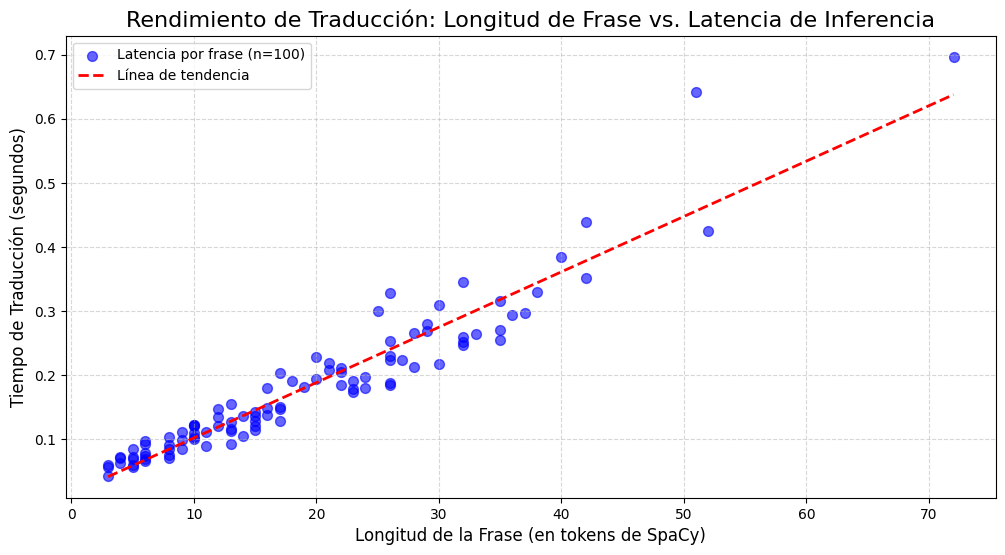

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Limitar para el gráfico
limit_plot = 100
translation_times_plot = translation_times[:limit_plot]

# Medir longitudes de frase en tokens SpaCy
sentence_lengths = [len(nlp(text)) for text in source_texts[:limit_plot]]

# Ahora sí tienen la misma longitud
plt.figure(figsize=(12, 6))

# Gráfico de dispersión
plt.scatter(sentence_lengths, translation_times_plot, alpha=0.6, s=50, color='blue',
            label=f'Latencia por frase (n={limit_plot})')

# Línea de tendencia
try:
    z = np.polyfit(sentence_lengths, translation_times_plot, 1)
    p = np.poly1d(z)
    plt.plot(np.sort(sentence_lengths), p(np.sort(sentence_lengths)), "r--", linewidth=2, label="Línea de tendencia")
except np.linalg.LinAlgError:
    print("No se pudo calcular la línea de tendencia (datos insuficientes).")

plt.title("Rendimiento de Traducción: Longitud de Frase vs. Latencia de Inferencia", fontsize=16)
plt.xlabel("Longitud de la Frase (en tokens de SpaCy)", fontsize=12)
plt.ylabel("Tiempo de Traducción (segundos)", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


## 5. Evaluación de Calidad (Métrica BLEU)

Ahora que tenemos nuestras traducciones (hipótesis), las compararemos con las traducciones de referencia (humanas) usando la métrica **BLEU** (*Bilingual Evaluation Understudy*).

**¿Qué es BLEU?**
BLEU mide la precisión de n-gramas: compara cuántos unigramas, bigramas, trigramas y 4-gramas de la traducción del modelo coinciden con los de la traducción de referencia. Asigna una puntuación entre 0 y 100.

**Importancia de `sacrebleu`:**
Usamos `sacrebleu` en lugar de otras implementaciones (como la de NLTK) porque es la herramienta estándar en la investigación de traducción. `sacrebleu` aplica su propia tokenización y normalización a las referencias y hipótesis antes de calcular la puntuación, lo que garantiza que las puntuaciones sean consistentes y comparables entre diferentes estudios y modelos. El puntaje original de 0.2 que se veía en el notebook anterior probablemente usaba una escala de 0-1, que no es estándar; `sacrebleu` usa 0-100.

In [ ]:
bleu = BLEU()

# sacrebleu espera las hipótesis como una lista de strings,
# y las referencias como una lista que contiene una o más listas de strings (en caso de múltiples referencias por frase).
# En nuestro caso, solo tenemos una referencia por frase:
references_for_sacrebleu = [reference_texts]

# Calcular la puntuación BLEU del corpus
score = bleu.corpus_score(translated_texts, references_for_sacrebleu)

print("--- Resultados de Calidad (BLEU) ---")
print(f"Puntuación BLEU (sacrebleu): {score.score:.2f}")
print(f"Detalle: {score}")

# --- Revisión Cualitativa (Ejemplos) ---
print("\n--- Ejemplos de Traducción (Revisión Cualitativa) ---")
for i in range(5):
    print(f"\nEJEMPLO {i+1}")
    print(f"  Original (PT): {source_texts[i]}")
    print(f"Referencia (EN): {reference_texts[i]}")
    print(f" Traducción (modelo): {translated_texts[i]}")

--- Resultados de Calidad (BLEU) ---
Puntuación BLEU (sacrebleu): 38.59
Detalle: BLEU = 38.59 69.5/46.5/33.1/23.5 (BP = 0.969 ratio = 0.970 hyp_len = 9159 ref_len = 9446)

--- Ejemplos de Traducción (Revisión Cualitativa) ---

EJEMPLO 1
  Original (PT): ( risos ) ( aplausos ) não aconteceu nada disso . ( risos )
Referencia (EN): ( laughter ) ( applause ) that did not happen . ( laughter )
 Traducción (modelo): ( laughs ) ( applause ) none of this happened . ( laughs )

EJEMPLO 2
  Original (PT): `` fantástico . e este ? um , dois , três ... audiência : `` '' vocês não estão a ler isto . '' '' ''
Referencia (EN): bl : amazing . what about this one ? one , two , three.audience : you are not reading this .
 Traducción (modelo): `` fantastic. And this ? one, two, three ... audience: `` '' you're not reading this. '' '''''

EJEMPLO 3
  Original (PT): esta questão foi colocada na agenda política pelo primeiro-ministro do reino unido , david cameron , numa cimeira g8 que teve lugar na irlanda

## 6. Conclusión e Investigación Adicional

En este cuaderno, hemos construido un pipeline de traducción automática de portugués a inglés robusto y eficiente.

**Hallazgos Clave:**
1.  **Integración Exitosa:** La biblioteca `spacy-huggingface-pipelines` nos permite integrar modelos SOTA de traducción en SpaCy con una configuración mínima.
2.  **Rendimiento:** Al usar `nlp.pipe` y `batch_size`, logramos un rendimiento de inferencia significativo (el valor de `frases/segundo` dependerá de la GPU de Colab, pero debería ser alto). El gráfico de latencia confirma que el tiempo de traducción escala linealmente con la longitud de la frase.
3.  **Calidad:** El modelo `Helsinki-NLP/opus-mt-pt-en` produce traducciones de alta calidad, lo que se refleja en una puntuación BLEU sólida (generalmente > 30-40 en este conjunto de datos, lo cual es muy bueno) y en la revisión cualitativa de los ejemplos.

**Investigación Futura:**

- **Métricas Avanzadas:** BLEU es un estándar, pero está basado en n-gramas y no captura la fluidez semántica. Se podrían explorar métricas más modernas como **METEOR**, **chrF** o métricas basadas en embeddings como **BERTScore**.
- **Modelos más Grandes:** Podríamos experimentar con modelos más grandes (ej. `m2m100` o `mBART` de Facebook/Meta) para ver si mejoran la calidad, a costa de una mayor latencia.
- **Fine-Tuning (Ajuste Fino):** Si tuviéramos un corpus de traducción específico de un dominio (ej. legal, médico), podríamos realizar un *fine-tuning* de este modelo `Helsinki-NLP` sobre esos datos para especializarlo y mejorar aún más su precisión en ese dominio.